
# Computer Vision with Convolutional Neural Networks

**Clean & Modern Template (Keras 3 Compatible)**

This notebook demonstrates:
1. Clean imports & structure  
2. Image data exploration  
3. Data augmentation (modern Keras)  
4. Before vs After visualization  
5. Best-practice model training with augmentation  

---



## 1. Imports & Environment Setup


In [3]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from keras import datasets

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0



## 2. Dataset Preparation
Assumption:
- `train_images`, `train_labels` already loaded
- Shape: (N, H, W, C)


In [4]:
#  LOAD AND SPLIT DATASET
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Example sanity check
print("Train images shape:", train_images.shape)


Train images shape: (50000, 32, 32, 3)



## 3. Visualizing Original Images


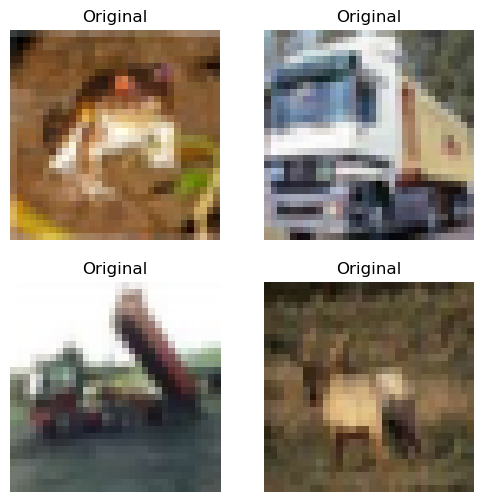

In [5]:

plt.figure(figsize=(6,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(train_images[i])
    plt.title("Original")
    plt.axis("off")
plt.show()



## 4. Data Augmentation (Modern Keras)
This replaces ImageDataGenerator (deprecated).


In [6]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
])



## 5. Before vs After Augmentation


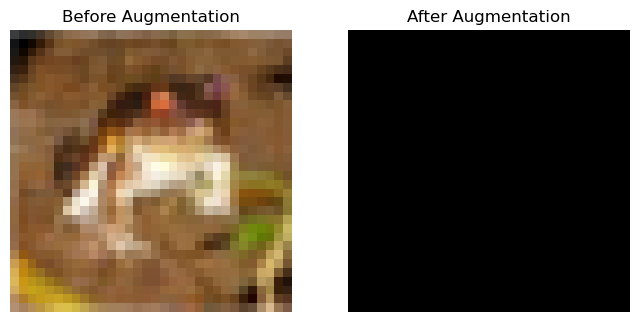

In [7]:

img = tf.expand_dims(train_images[0], axis=0)

plt.figure(figsize=(8,4))

# Before
plt.subplot(1,2,1)
plt.imshow(train_images[0])
plt.title("Before Augmentation")
plt.axis("off")

# After
aug_img = data_augmentation(img, training=True)
plt.subplot(1,2,2)
plt.imshow(tf.cast(aug_img[0], tf.uint8))
plt.title("After Augmentation")
plt.axis("off")

plt.show()



## 6. Model Definition (Best Practice)
Augmentation is part of the model.


In [8]:

model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 30, 30, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 15, 15, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 13, 13, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 6, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 2304)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 64)                │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 10)                │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)


## 7. Model Training


In [9]:

history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.0983 - loss: 2.3028 - val_accuracy: 0.0997 - val_loss: 2.3028
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.0995 - loss: 2.3027 - val_accuracy: 0.0977 - val_loss: 2.3027
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.0990 - loss: 2.3028 - val_accuracy: 0.0980 - val_loss: 2.3028
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.0977 - loss: 2.3028 - val_accuracy: 0.0952 - val_loss: 2.3028
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.1001 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3029
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.0998 - loss: 2.3028 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.0987 - loss: 2.3028 - val_accuracy: 0.0977 - val_loss: 2.3028
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.1001 -


## 8. Training Visualization


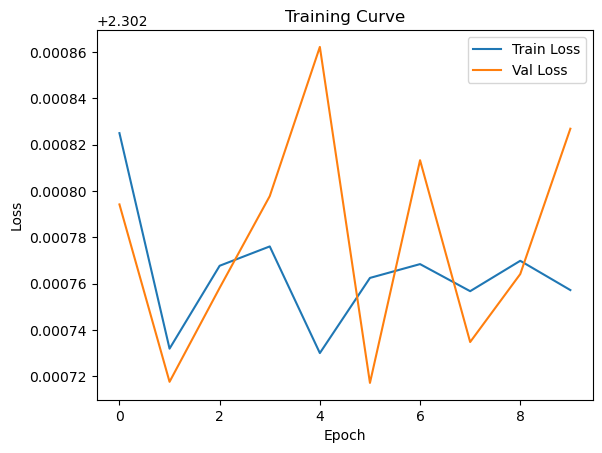

In [10]:

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()



## 9. Conclusion

This notebook follows:
- Modern Keras API (no deprecated code)
- Academic clarity
- Industry best practices
